# 1- Business Understanding

---

#  Project Overview

Credit card fraud represents one of the most critical challenges in the financial industry. Fraudulent transactions can lead to significant financial losses, reduced customer trust, and increased operational costs for financial institutions.

The objective of this project is to develop a machine learning system capable of detecting fraudulent credit card transactions based on historical transaction data. By accurately identifying suspicious transactions, businesses can proactively prevent fraud and improve customer security.

This project explores multiple machine learning and deep learning approaches for fraud detection while focusing on the challenges associated with highly imbalanced datasets.

---

#  Business Problem

Financial institutions process millions of transactions daily, making manual fraud detection nearly impossible. Fraudulent transactions represent only a very small fraction of total transactions, which creates a significant class imbalance problem.

The main business challenge is to correctly identify fraudulent transactions while minimizing false alarms on legitimate customer transactions.

Fraud detection systems must balance two important objectives:

- Detect as many fraudulent transactions as possible.
- Avoid incorrectly flagging legitimate customer activity.

Missing fraudulent transactions can result in severe financial and reputational damage, while excessive false positives may negatively impact customer experience.

---

#  Machine Learning Objective

The machine learning objective of this project is to build classification models capable of distinguishing between:

- Legitimate transactions (`Class = 0`)
- Fraudulent transactions (`Class = 1`)

The project will evaluate several machine learning algorithms and compare their ability to detect fraudulent behavior under severe class imbalance conditions.

Special attention will be given to:

- Recall for the fraud class
- Precision-recall tradeoff
- Imbalanced data handling techniques
- Model generalization performance

---

#  Dataset Information

The dataset used in this project is the well-known Credit Card Fraud Detection dataset published by the Machine Learning Group of Université Libre de Bruxelles (ULB).

Dataset characteristics:

- Transactions made by European cardholders
- Highly imbalanced dataset
- Fraudulent transactions represent a very small percentage of all observations
- Features are anonymized using PCA transformation for privacy protection

The dataset contains:

- Numerical transaction features (`V1` to `V28`)
- Transaction time
- Transaction amount
- Target variable (`Class`)

---

#  Project Goals

The main goals of this project are:

- Perform exploratory data analysis on transaction behavior
- Investigate class imbalance challenges
- Apply preprocessing and feature engineering techniques
- Experiment with multiple machine learning models
- Evaluate models using appropriate fraud detection metrics
- Improve fraud detection performance using imbalance handling techniques
- Generate business insights and recommendations

---

#  Success Metrics

Since the dataset is highly imbalanced, accuracy alone is not sufficient for evaluating model performance.

The project will focus on the following evaluation metrics:

- Recall Score
- Precision Score
- F1-Score
- ROC-AUC Score
- Confusion Matrix
- Precision-Recall Tradeoff

Particular importance will be given to fraud recall, as failing to detect fraudulent transactions can be extremely costly in real-world financial systems.

---

#  Technologies Used

This project will primarily use the following tools and libraries:

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TensorFlow / Keras
- Imbalanced-learn (SMOTE)

---

#  Project Workflow

The project will follow the following workflow:

1. Business Understanding
2. Data Understanding
3. Exploratory Data Analysis
4. Data Cleaning
5. Feature Engineering & Preprocessing
6. Handling Imbalanced Data
7. Machine Learning Modeling
8. Model Evaluation & Comparison
9. Business Insights & Recommendations

```

# 2- Imports & Environment Setup :

In this section, we will import all the necessary Python libraries required for data manipulation, visualization, machine learning, and model evaluation.

We will also configure some notebook settings to improve readability and visualization quality throughout the project.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

In [3]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [5]:
# Notebook Configuration:
import warnings
warnings.filterwarnings('ignore')

# 3- Data loading & Initial Exploration

In [6]:
#loading the data:
transaction_data = pd.read_csv('../Data/creditcard.csv')

In [7]:
transaction_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


- The dataset contains anonymized credit card transaction information along with a binary target variable indicating fraudulent activity.

In [8]:
# the shape:
transaction_data.shape

(284807, 31)

In [9]:
transaction_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [10]:
transaction_data['Class'].value_counts() / len(transaction_data) * 100

Class
0    99.827251
1     0.172749
Name: count, dtype: float64

<Axes: ylabel='count'>

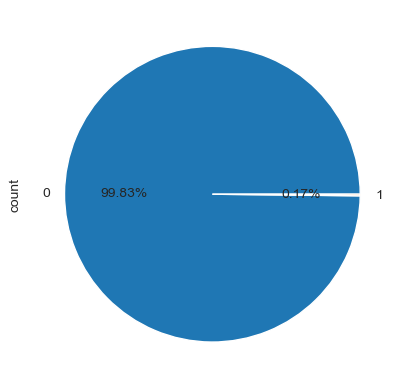

In [11]:
transaction_data['Class'].value_counts().plot.pie(
    autopct='%1.2f%%',
)

- The dataset is extremely imbalanced. Fraudulent transactions represent only a very small fraction of all observations, making fraud detection significantly more challenging. Traditional machine learning models may become biased toward the majority class.

In [12]:
# checking the columns type :
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [13]:
#some statistical :
transaction_data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [14]:
# all columns:
transaction_data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [15]:
# stirng and categorical columns:
transaction_data.select_dtypes(exclude='number').columns

Index([], dtype='object')

- features V1–V28 were transformed using PCA for privacy reasons
- feature interpretability is limited.

In [16]:
## checking missing values:
transaction_data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [17]:
# checking for duplicated rows:
transaction_data.duplicated().sum()

np.int64(1081)

In [18]:
## removing the duplicated rows:
transaction_data = transaction_data.drop_duplicates()

In [19]:
transaction_data.duplicated().sum()

np.int64(0)

- Duplicate observations were detected in the dataset and removed to avoid potential bias during model training and evaluation. Duplicate transactions could lead to data leakage or artificially inflated model performance.

# Initial Observations:
- The dataset contains highly imbalanced classes.
- No missing values were detected.
- All features are numerical.
- Most features are anonymized PCA-transformed variables.
- Fraud detection will require careful handling of imbalance during modeling.
- Accuracy alone will not be sufficient for evaluation.

# 4- Exploratory Data Analysis (EDA):

# 4.1- Class Distribution Analysis :

Text(0.5, 1.0, 'Class Distrubtions')

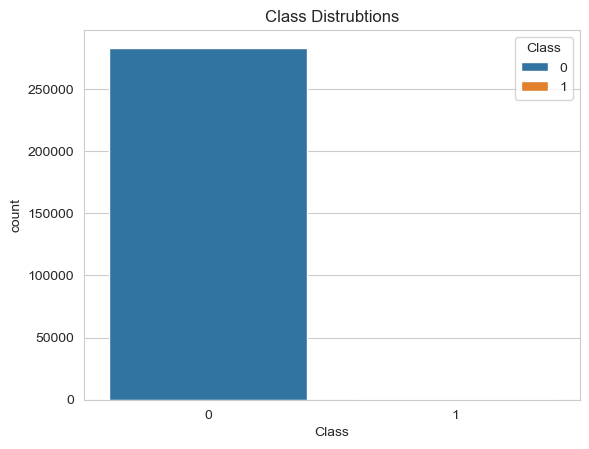

In [20]:
sns.countplot(data=transaction_data, x='Class', hue='Class')
plt.title('Class Distrubtions')

- The dataset is extremely imbalanced, with fraudulent transactions representing only a very small percentage of total observations. This imbalance presents a major challenge for machine learning models, as they may become biased toward the majority class.

# 4.2- Trasaction Amounts Analysis:

Text(0.5, 1.0, 'trasaction amount destribution')

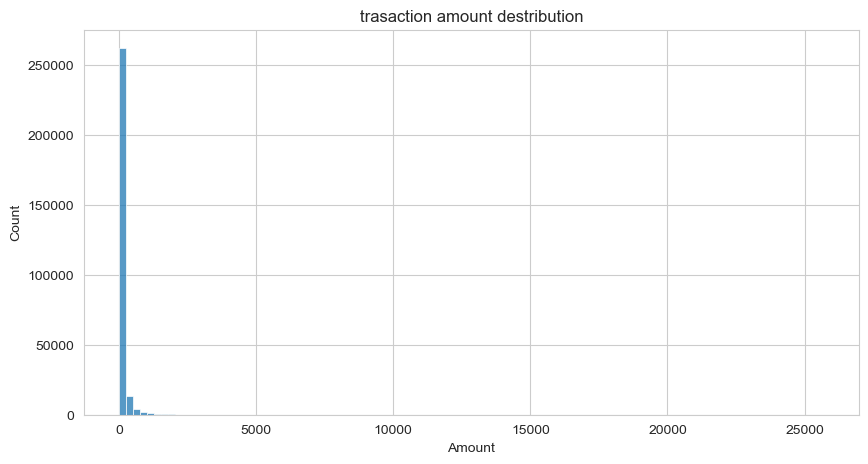

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(data=transaction_data, x='Amount', bins=100)
plt.title('trasaction amount destribution')

In [22]:
transaction_data.groupby('Class')['Amount'].value_counts()

Class  Amount 
0      1.00       13461
       1.98        6044
       0.89        4871
       9.99        4737
       15.00       3280
                  ...  
1      1389.56        1
       1402.16        1
       1504.93        1
       1809.68        1
       2125.87        1
Name: count, Length: 32960, dtype: int64

In [23]:
transaction_data.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


Text(0.5, 1.0, 'Transaction amount by Class')

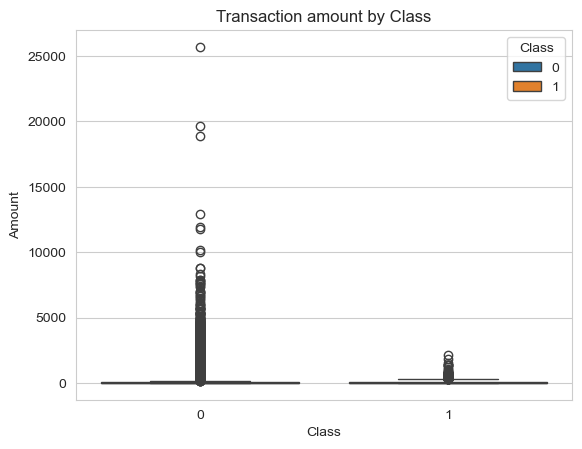

In [24]:
sns.boxplot(data=transaction_data, x='Class', y='Amount', hue='Class')
plt.title('Transaction amount by Class')

- we can already tell that transaction amount are mostly in small amount than higher ones.
- also fraud transaction have have lower amount than legitimate transaction.
- legitimate transactions appear to contain more extreme outliers.
- many small transactions and few extremely large ones

# 4.3 TIME Feature Analysis :

Text(0.5, 1.0, 'Transaction Time Distribution')

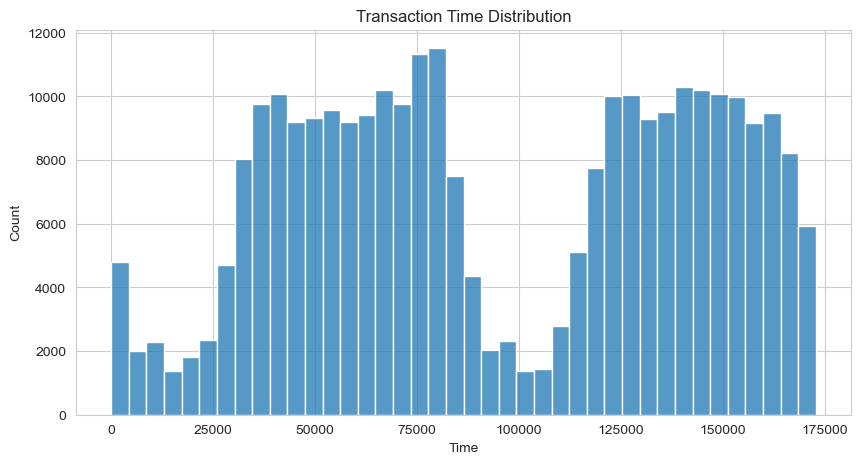

In [25]:
# time feature is actually seconds collapsed not real timestamp:
plt.figure(figsize=(10,5))
sns.histplot(data=transaction_data, x='Time', bins=40)
plt.title('Transaction Time Distribution')

In [26]:
transaction_data.groupby('Class')['Time'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,94835.058093,47475.550607,0.0,54233.0,84711.0,139308.0,172792.0
1,473.0,80450.513742,48636.179973,406.0,41203.0,73408.0,129095.0,170348.0


Text(0.5, 1.0, 'Fraud Transaction Over Time')

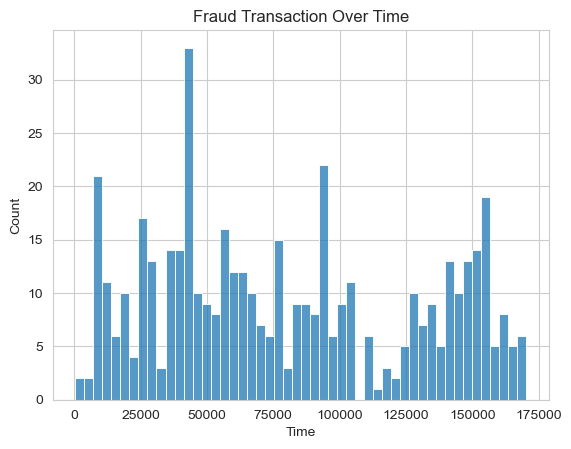

In [27]:
# trying to see fraud behavior over time :
fraud = transaction_data[transaction_data['Class'] == 1]
sns.histplot(fraud['Time'], bins=50)
plt.title('Fraud Transaction Over Time')

- we can notice some suspecious burst
- maybe some temporal patterns

# Time Vs Amount

<Axes: xlabel='Time', ylabel='Amount'>

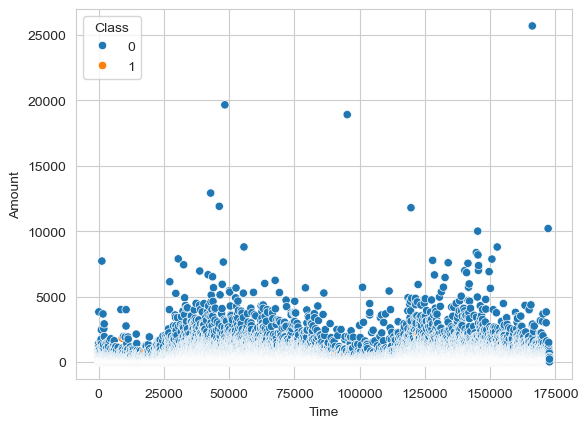

In [28]:
sns.scatterplot(data=transaction_data, x='Time', y='Amount', hue='Class')

<Axes: xlabel='Time', ylabel='Amount'>

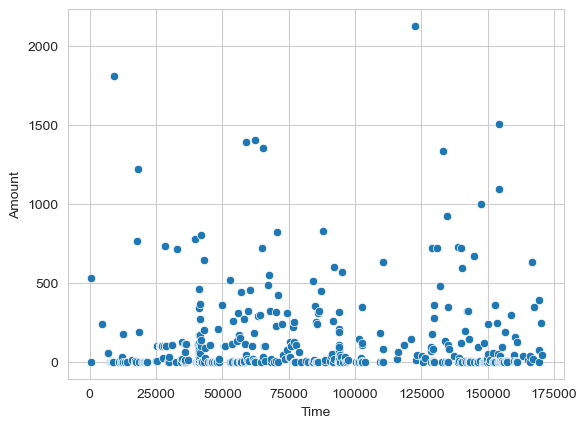

In [29]:
sns.scatterplot(data=fraud, x='Time', y='Amount')

- we notice there is almost no deference in time for frad and not fraud transactions.
- also we oobservce that fraud transaction amount are significantly smaller and cluster between 1 to 2000 $, excluding some outliers.

# 4.4 Fraud Vs Non-fraud Comparaison :

since datset is extremly impacanced im goiding to sample the the data set just to see some visuals :

In [30]:
fraud = transaction_data[transaction_data['Class'] == 1]

normal_sample = transaction_data[transaction_data['Class'] == 0].sample(
    len(fraud),
    random_state=42
)

balanced_vis = pd.concat([fraud, normal_sample], axis=0)

<Axes: xlabel='Amount', ylabel='Density'>

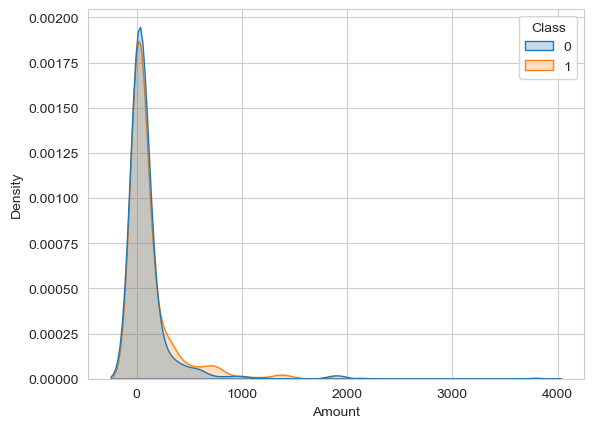

In [31]:
sns.kdeplot(
    data=balanced_vis,
    x='Amount',
    hue='Class',
    fill=True
)

<Axes: xlabel='Time', ylabel='Density'>

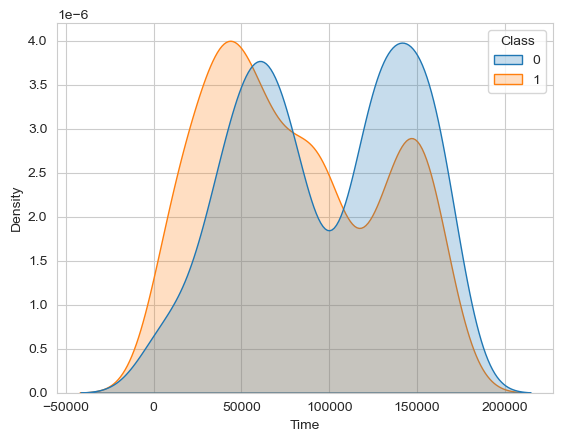

In [32]:
sns.kdeplot(
    data=balanced_vis,
    x='Time',
    hue='Class',
    fill=True
)

<Axes: xlabel='V1', ylabel='Density'>

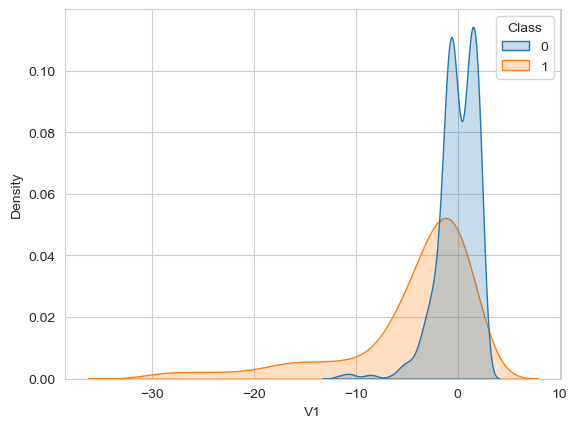

In [33]:
sns.kdeplot(
    data=balanced_vis,
    x='V1',
    hue='Class',
    fill=True
)

<Axes: xlabel='V2', ylabel='Density'>

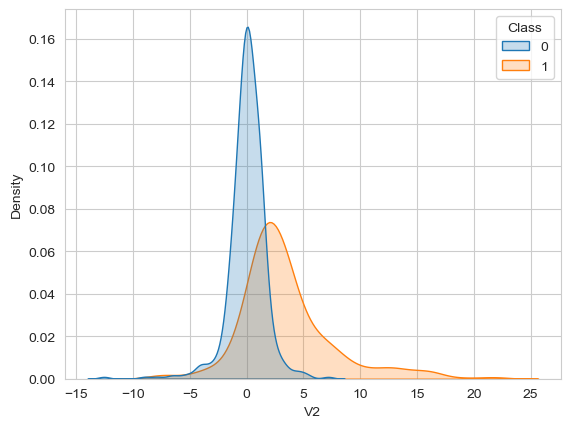

In [34]:
sns.kdeplot(
    data=balanced_vis,
    x='V2',
    hue='Class',
    fill=True
)

<Axes: xlabel='V3', ylabel='Density'>

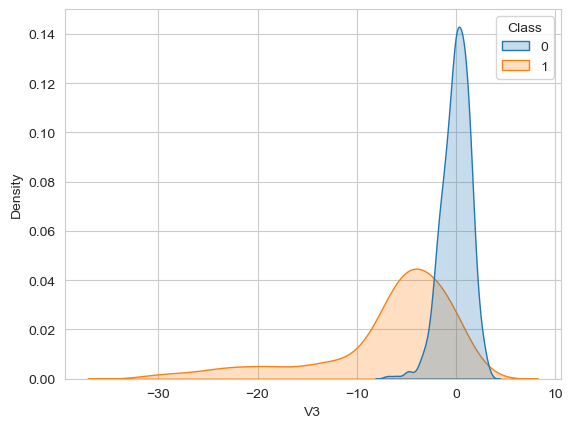

In [35]:
sns.kdeplot(
    data=balanced_vis,
    x='V3',
    hue='Class',
    fill=True
)

<Axes: xlabel='V4', ylabel='Density'>

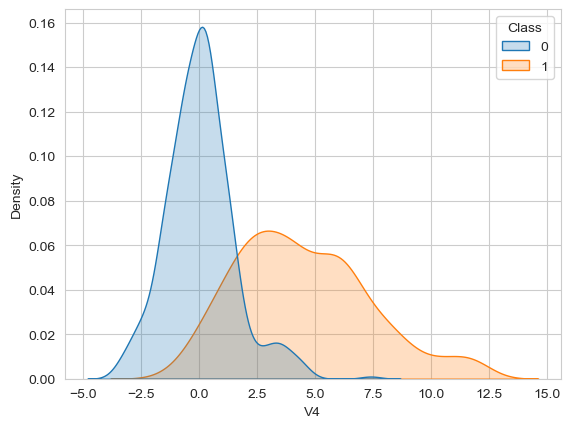

In [36]:
sns.kdeplot(
    data=balanced_vis,
    x='V4',
    hue='Class',
    fill=True
)

<Axes: xlabel='V11', ylabel='Density'>

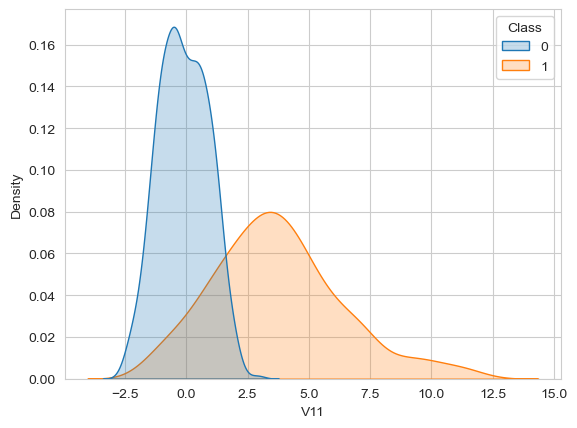

In [37]:
sns.kdeplot(
    data=balanced_vis,
    x='V11',
    hue='Class',
    fill=True
)

<Axes: xlabel='V12', ylabel='Density'>

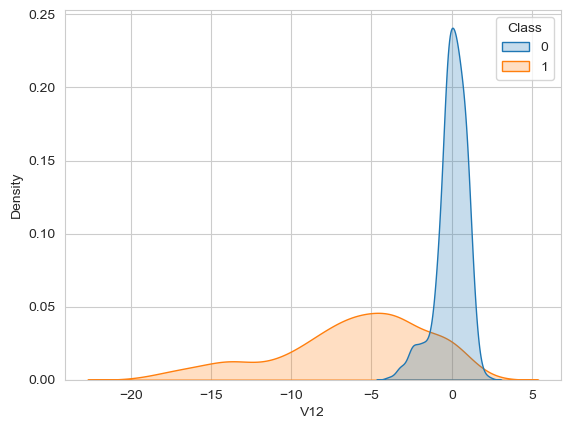

In [38]:
sns.kdeplot(
    data=balanced_vis,
    x='V12',
    hue='Class',
    fill=True
)

<Axes: xlabel='V14', ylabel='Density'>

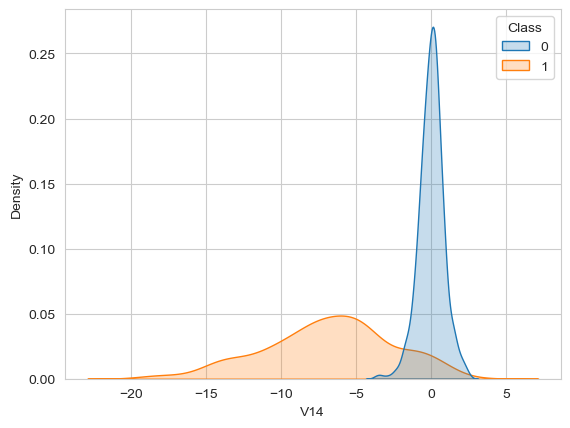

In [39]:
sns.kdeplot(
    data=balanced_vis,
    x='V14',
    hue='Class',
    fill=True
)

<Axes: xlabel='V17', ylabel='Density'>

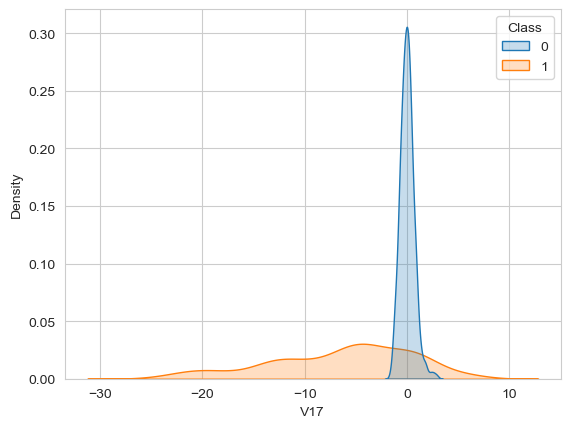

In [40]:
sns.kdeplot(
    data=balanced_vis,
    x='V17',
    hue='Class',
    fill=True
)

- After analysig very feature, we notice that fraud trasaction have deferent patterns and ditribution compared to non fraud transaction which are distributed normally centred around the zero.
- Fraudulent transactions show different distribution patterns across several PCA-transformed variables.
- So some PCA variables may strongly separate classes.

# 4.5 Correlation Analysis :

<Axes: >

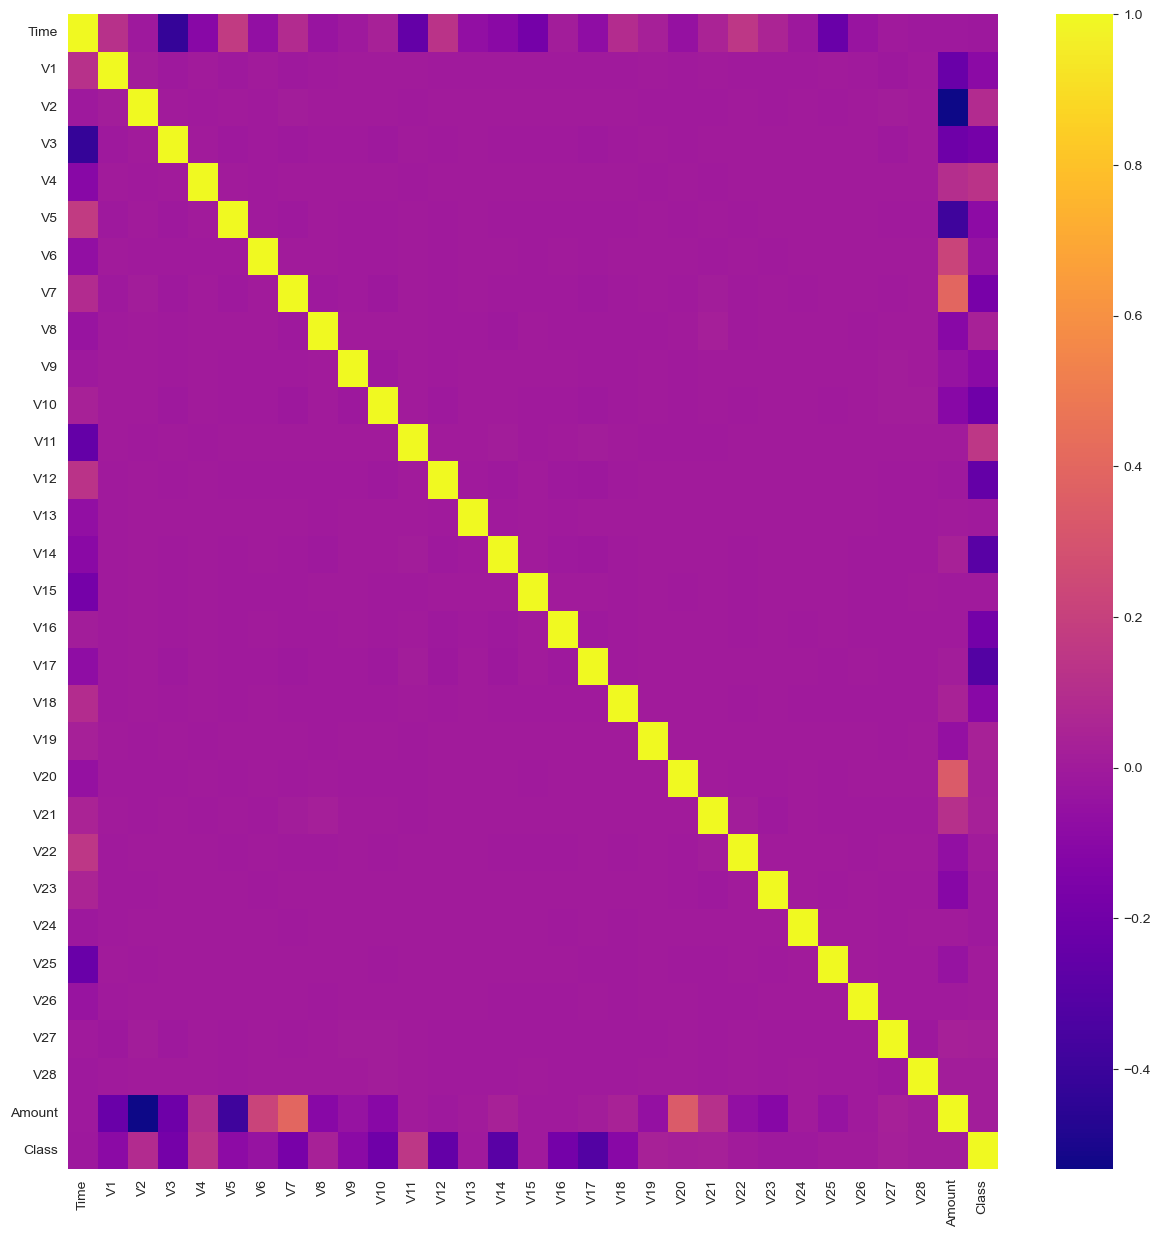

In [41]:
# features correlation matrix:
plt.figure(figsize=(15,15))
sns.heatmap(data=transaction_data.corr(), cmap='plasma')

In [42]:
class_corr = transaction_data.corr()['Class'].sort_values()

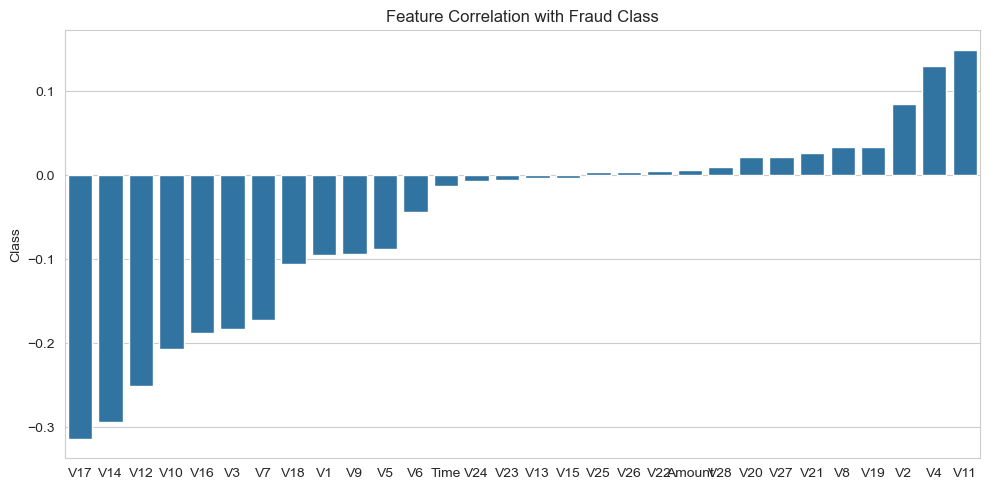

In [47]:
plt.figure(figsize=(10,5))
sns.barplot(data=class_corr.drop('Class'))
plt.title('Feature Correlation with Fraud Class')
plt.tight_layout()

- we can see that PCA geerated features have no correlations between them.
- and some of them have slighltly correlited to amount and time as well Class, very small correlation. 

# Key Key Findings (EDA Summary):

- The dataset is highly imbalanced with very few fraudulent transactions.
- Transaction amounts are heavily right-skewed with several extreme outliers.
- Fraudulent transactions show different distribution patterns across several PCA-transformed variables.
- Several PCA-transformed features exhibit non-normal distributions and contain extreme values, which may indicate useful patterns for fraud detection models.
- Outliers may contain meaningful fraud-related information and should not be removed blindly.
- Class imbalance handling will be critical during model training.

# 5- Cleaning Data :
- Duplicate observations were removed.
- No missing values were detected.
- All features were already numerical.
- No additional cleaning was required.

# 6- Data preprossecing:

# 6.1- creating the X and y : 

In [48]:
transaction_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [49]:
X = transaction_data.drop('Class', axis=1)

In [50]:
y = transaction_data['Class']

# 6.2- Train & Test split:

In [51]:
# 6.2- split data into Train & Test data:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

- we used stratify because the dataset is imbalanced, so we use this param to make same fraud ratio in train and test

# 6.3- Scale Data :

- PCA features already scaled-like, and Time and Amount are not normalized, so we need to scale only this two features.

In [52]:
# creating a scaler:
scaler = StandardScaler()

In [53]:
# fiting the scaler only to the training data :
scaler.fit(X_train[['Time', 'Amount']])

,copy,True
,with_mean,True
,with_std,True


In [54]:
# now we transform both test and train X data :
X_train[['Time', 'Amount']] = scaler.transform(X_train[['Time', 'Amount']])

In [55]:
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# 6.4- Dealing with Imbalaced data (Most Important part) :

- we hve extreme imbalanced data: with huge obersavation non fradu and only small less then 0.18% of them are fraud observations.
- if we train our model using the real data samples : models become biased toward majority class. which s bad for us
- model may predict everything is good no frau with acuracy 98 or more , accuracy becomes misleading.
- we could use undersampling or oversampling but the best one to chose here is SMOTE method as the fowling to deal with imbalaced dataset.

# we only going to apply smot and balace the rain data not the test data.

In [56]:
# creating the smote object:
smote = SMOTE(random_state=42)

In [57]:
# pplying it to training data:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [58]:
# now we compare and verify the result:
y_train.value_counts()

Class
0    212439
1       355
Name: count, dtype: int64

In [59]:
y_train_smote.value_counts()

Class
0    212439
1    212439
Name: count, dtype: int64

- now the classes are balanced using smote.

- smote analyzed fraud samples, generated synthetic fraud observations and we got balanced training dataset.
- Now model learns fraud patterns MUCH better

# Preprocessing Summary :
- The dataset was split using stratified sampling to preserve class distribution.
- Time and Amount features were scaled using StandardScaler.
- SMOTE oversampling was applied only to the training set.
- The test set remained untouched to ensure realistic evaluation.

# 7- Modeling and Evaluation Models :

- In fraud detection: false negatives are dangerous, means fraud transaction missed , Which causes financial loss.
- that's wahy the recall metric is the most important here not accuracy

In [60]:
# before we start we create  and evaluation function to reuse:
def evaluate_model(y_test, preds):

    print(classification_report(y_test, preds))

    print('\n')

    print(confusion_matrix(y_test, preds))

# 7.1- Logistic Regression:

In [99]:
# creating the model :
log_model = LogisticRegression(class_weight='balanced', random_state=42)

In [100]:
# trainig the model : 
log_model.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [66]:
# testing the model :
log_preds = log_model.predict(X_test)

In [67]:
# evaluating the model :
evaluate_model(y_test, log_preds)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     70814
           1       0.05      0.88      0.10       118

    accuracy                           0.97     70932
   macro avg       0.53      0.93      0.54     70932
weighted avg       1.00      0.97      0.98     70932



[[68912  1902]
 [   14   104]]


Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

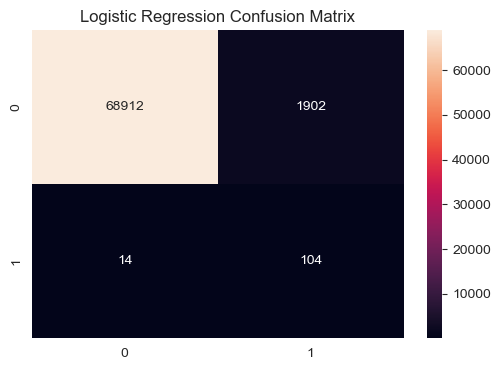

In [68]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, log_preds),
    annot=True,
    fmt='d'
)

plt.title('Logistic Regression Confusion Matrix')

- Logistic Regression achieved extremely high fraud recall (88%), correctly detecting 104 out of 118 fraudulent transactions while missing only 14 fraud cases — the lowest false negatives among all models. However, this strong fraud sensitivity came at the cost of a very high number of false positives (1902), resulting in extremely low fraud precision (5%). 

- This means the model aggressively flagged transactions as fraudulent, making it effective for maximizing fraud detection but impractical for real-world deployment without additional filtering systems.

# 7.2- KNN:

In [69]:
# first we try to fnd the best K neighbors using this method :
error_rate = []

for i in range(1,40):
    knn_i = KNeighborsClassifier(n_neighbors=i)
    knn_i.fit(X_train_smote, y_train_smote)
    knn_i_preds = knn_i.predict(X_test)
    error_rate.append(np.mean(knn_i_preds != y_test))

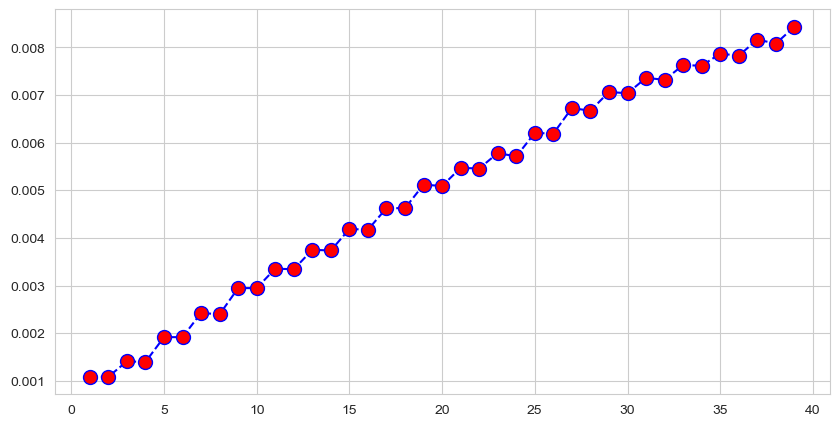

In [72]:
## now ploting the error rate :
plt.figure(figsize=(10,5))
plt.plot(range(1,40), error_rate, color='blue', ls='--', marker='o', markerfacecolor='red', markersize=10)

In [104]:
# we can see that the best one is K=1:
# so we can start again with this k:
knn_model = KNeighborsClassifier(n_neighbors=1)

In [105]:
# train the model: 
knn_model.fit(X_train_smote, y_train_smote)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [75]:
# test the model :
knn_preds = knn_model.predict(X_test)

In [76]:
# Evaluate the model :
evaluate_model(y_test, knn_preds)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.65      0.76      0.70       118

    accuracy                           1.00     70932
   macro avg       0.82      0.88      0.85     70932
weighted avg       1.00      1.00      1.00     70932



[[70765    49]
 [   28    90]]


Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

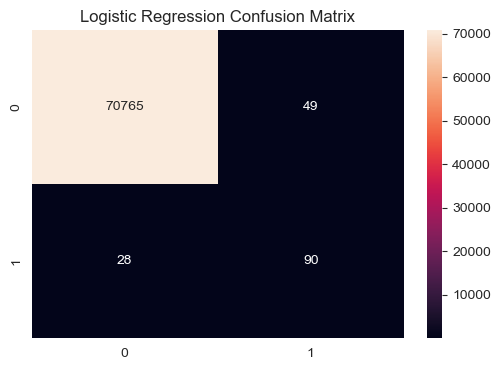

In [77]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, knn_preds),
    annot=True,
    fmt='d'
)

plt.title('Logistic Regression Confusion Matrix')

- KNN delivered one of the strongest overall performances in the project with 76% fraud recall and 65% precision. The model correctly detected 90 fraudulent transactions while generating only 49 false positives, which is a massive improvement over Logistic Regression and SVM.

- KNN achieved a very strong balance between fraud detection capability and false alarm reduction, making it one of the most efficient models in the project.

# 7.3- Support Vecture Machine (SVM)

In [78]:
# creating the model :
svc_model = SVC(class_weight='balanced')

In [79]:
# training the model :
svc_model.fit(X_train_smote, y_train_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [80]:
svc_preds = svc_model.predict(X_test)

In [81]:
# we evaluate the model: 
evaluate_model(y_test, svc_preds)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     70814
           1       0.09      0.88      0.17       118

    accuracy                           0.99     70932
   macro avg       0.55      0.93      0.58     70932
weighted avg       1.00      0.99      0.99     70932



[[69803  1011]
 [   14   104]]


Text(0.5, 1.0, 'SVC Confusion Matrix')

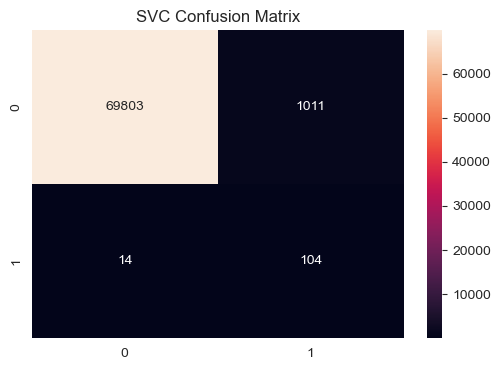

In [82]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, svc_preds),
    annot=True,
    fmt='d'
)

plt.title('SVC Confusion Matrix')

- The SVM model achieved the same fraud recall as Logistic Regression (88%) by correctly identifying 104 fraud cases and missing only 14 fraudulent transactions. However, the model still generated a very large number of false positives (1011), resulting in poor fraud precision (9%).

- Although SVM was highly sensitive to fraud detection, its excessive false positive rate would create major operational challenges in real-world financial systems.

In [83]:
## the result were good but , we will try gridsearchcv to try imporove the model and see:
# first we create a param_grid:
param_grid = {
    'C':[0.1, 1, 10, 100],
    'gamma':[1, 0.1, 0.01, 0.001]
}

In [84]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2)

- i couldn't use this grid to fit 80 times and that's because it take too muuh time using my pc.
- but the result was the best until now the model prediction model was this SVC

# 7.4- Decession Tree :

In [61]:
tree_model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [62]:
## training the model :
tree_model.fit(X_train_smote, y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [63]:
# testing the model :
tree_preds = tree_model.predict(X_test)

In [64]:
# evaluations: 
evaluate_model(y_test, tree_preds)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.39      0.74      0.51       118

    accuracy                           1.00     70932
   macro avg       0.69      0.87      0.75     70932
weighted avg       1.00      1.00      1.00     70932



[[70676   138]
 [   31    87]]


Text(0.5, 1.0, 'Decession tree Confusion Matrix')

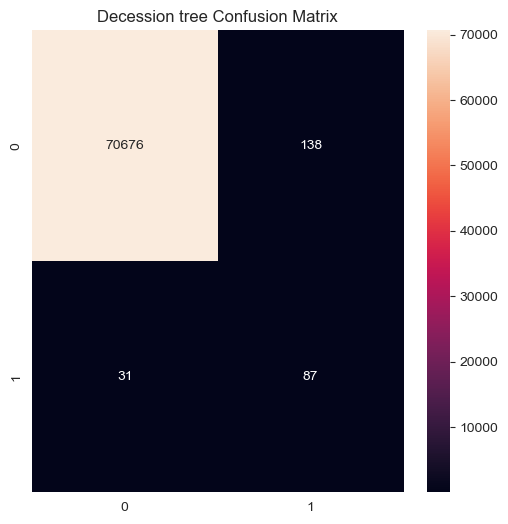

In [65]:
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, tree_preds), annot=True, fmt='d')
plt.title('Decession tree Confusion Matrix')

- The Decision Tree model showed weaker overall fraud detection performance compared to the other models. It correctly detected 87 fraud cases while missing 31 fraudulent transactions and generating 138 false positives.

- Although the model achieved acceptable recall (74%), its lower precision (39%) and weaker generalization indicate overfitting tendencies commonly associated with single decision trees.

# 7.5- Random Forest:

In [66]:
# creating the model :
rfc_model = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

In [67]:
# training the model:
rfc_model.fit(X_train_smote, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [68]:
# test the model :
rfc_preds = rfc_model.predict(X_test)

In [69]:
# evaluate: 
evaluate_model(y_test, rfc_preds)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.91      0.76      0.83       118

    accuracy                           1.00     70932
   macro avg       0.95      0.88      0.91     70932
weighted avg       1.00      1.00      1.00     70932



[[70805     9]
 [   28    90]]


Text(0.5, 1.0, 'Random Forest Confusion Matrix')

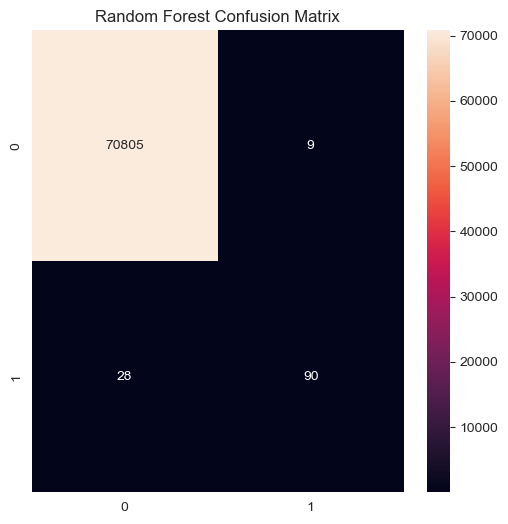

In [70]:
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, rfc_preds), annot=True, fmt='d')
plt.title('Random Forest Confusion Matrix')

- Random Forest achieved the best overall performance in the entire project. The model correctly identified 90 fraudulent transactions while generating only 9 false positives, resulting in an outstanding fraud precision of 91% and strong recall of 76%.

- Compared to all other models, Random Forest delivered the best balance between fraud detection effectiveness and false positive control, making it the most production-ready model in the project.

Text(0.5, 1.0, 'Top Feature Importance')

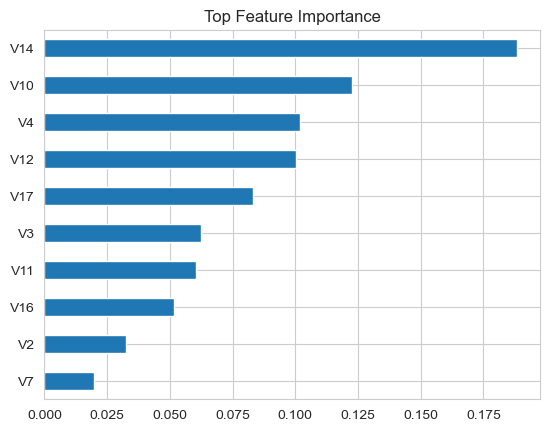

In [71]:
#ploting the features importance for random forest :
importance = pd.Series(
    rfc_model.feature_importances_,
    index=X_train.columns
)

importance.sort_values().tail(10).plot(
    kind='barh'
)

plt.title('Top Feature Importance')

# 7.6- XGboost model :

In [72]:
# Creating and Training the model :
xgb_model = XGBClassifier(
    scale_pos_weight=(
        len(y_train[y_train==0]) /
        len(y_train[y_train==1])
    ),
    random_state=42
)

In [73]:
# fiting the model :
xgb_model.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [74]:
xgb_preds = xgb_model.predict(X_test)

In [75]:
# evaluating the model :
evaluate_model(y_test, xgb_preds)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.55      0.81      0.66       118

    accuracy                           1.00     70932
   macro avg       0.78      0.91      0.83     70932
weighted avg       1.00      1.00      1.00     70932



[[70737    77]
 [   22    96]]


Text(0.5, 1.0, 'XGboost Model Confusion Matrix')

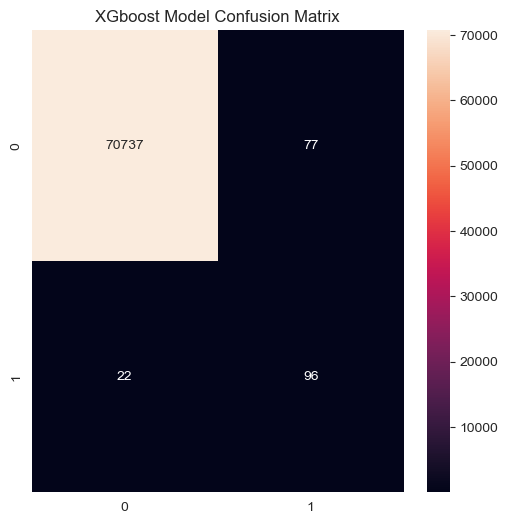

In [76]:
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, xgb_preds), annot=True, fmt='d')
plt.title('XGboost Model Confusion Matrix')

- XGBoost achieved very strong fraud detection performance with 81% fraud recall and 55% precision. The model correctly detected 96 fraud cases while generating 77 false positives.

- Compared to KNN and Random Forest, XGBoost detected more fraudulent transactions but at the cost of a higher false positive rate. The model demonstrated strong predictive power and excellent capability in handling the highly imbalanced dataset.

# 7.7- Nueral Network Model :

In [77]:
# checking the sahpe :
X.shape

(283726, 30)

In [78]:
# creating an early stop callbak:
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=10)

In [79]:
# creating the neural network:
nn_model = Sequential()

nn_model.add(Dense(30, activation='relu'))
nn_model.add(Dropout(0.3))

nn_model.add(Dense(15, activation='relu'))
nn_model.add(Dropout(0.3))

nn_model.add(Dense(1, activation='sigmoid'))

nn_model.compile(optimizer='adam', loss='binary_crossentropy')

In [80]:
# training the model :
nn_model.fit(x=X_train_smote, y=y_train_smote, validation_data=(X_test, y_test), epochs=100, callbacks=[early_stop])

Epoch 1/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 0.0655 - val_loss: 0.0232
Epoch 2/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0215 - val_loss: 0.0246
Epoch 3/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 0.0177 - val_loss: 0.0251
Epoch 4/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0158 - val_loss: 0.0270
Epoch 5/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0144 - val_loss: 0.0276
Epoch 6/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - loss: 0.0136 - val_loss: 0.0269
Epoch 7/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 0.0126 - val_loss: 0.0283
Epoch 8/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 0.0128 - val_loss: 0.0289
Epoch 9/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 0.0124 - val_loss: 0.0281
Epoch 10/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - loss: 0.0119 - val_loss: 0.0322
Epoch 11/100
13278/13278 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0113 - val

In [81]:
# creating the loses data farme:
losses = pd.DataFrame(nn_model.history.history)

<Axes: >

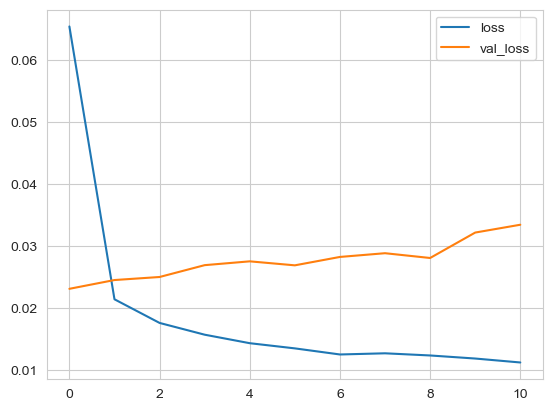

In [82]:
losses.plot()

we can tell that the model start to overfit because we did the patinece =10 and he found the best loss rate at the firest epochs, we culd recreate the model with small epocks. we try the model like this. 

In [89]:
nn_preds = nn_model.predict(X_test)

2217/2217 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [90]:
nn_preds

array([[0.0000000e+00],
       [0.0000000e+00],
       [1.1429865e-37],
       ...,
       [1.6796964e-13],
       [0.0000000e+00],
       [0.0000000e+00]], shape=(70932, 1), dtype=float32)

In [91]:
# converting probabilities to classes:
nn_preds_class = (nn_preds > 0.5).astype(int)

In [92]:
nn_preds_class

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(70932, 1))

In [93]:
# evaluating the model :
evaluate_model(y_test, nn_preds_class)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     70814
           1       0.55      0.82      0.66       118

    accuracy                           1.00     70932
   macro avg       0.77      0.91      0.83     70932
weighted avg       1.00      1.00      1.00     70932



[[70734    80]
 [   21    97]]


Text(0.5, 1.0, 'Neural Network Model Confusion Matrix')

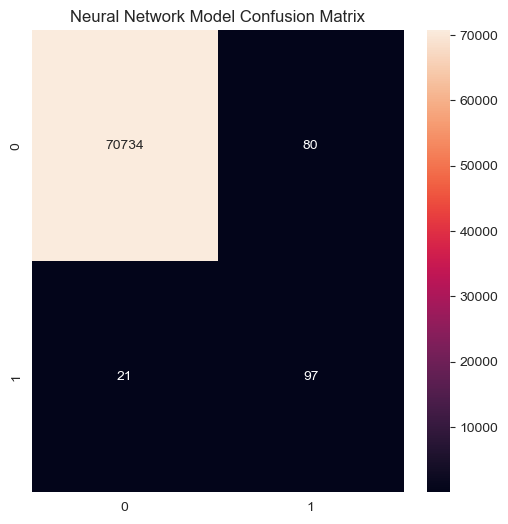

In [98]:
plt.figure(figsize=(6,6))
sns.heatmap(confusion_matrix(y_test, nn_preds_class), annot=True, fmt='d')
plt.title('Neural Network Model Confusion Matrix')

- The Neural Network achieved performance very similar to XGBoost with 82% fraud recall and 55% precision. The model correctly identified 97 fraudulent transactions while generating 80 false positives.

- The use of dropout layers and early stopping helped control overfitting and improved generalization. Although the Neural Network performed strongly, it did not outperform Random Forest in terms of overall balance between precision and recall.

# 7.8 ROC Curve & AUC Comparison

# 7.8.1- getting the probabilites for all model :

# A) Logistic Model Probabilities :

In [101]:
log_probs = log_model.predict_proba(X_test)[:,1]

In [102]:
# calculating the roc curve for logistic model:
log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)

In [103]:
# calculating the auc score for logistic model :
log_auc = roc_auc_score(y_test, log_probs)

# B) KNN Probabilities :

In [106]:
# getting the probabilities :
knn_probs = knn_model.predict_proba(X_test)[:,1]

In [107]:
# calculating the roc curve:
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)

In [108]:
# calculating the auc score:
knn_auc = roc_auc_score(y_test, knn_probs)

# C) SVC Probabilities :

- for svc we have to recreate the model using parameter probability to true:

In [109]:
# recreating the svc model :
Svc_model = SVC(
    class_weight='balanced',
    probability=True
)

In [110]:
Svc_model.fit(X_train_smote, y_train_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [111]:
svc_probs = Svc_model.predict_proba(X_test)[:,1]

In [112]:
# calculate the roc curve:
svc_fpr, svc_tpr, _ = roc_curve(y_test, svc_probs)

In [113]:
# calculate the auc score:
svc_auc = roc_auc_score(y_test,svc_probs)

# D) Decession Tree Probabilities :

In [114]:
# getting the probs:
tree_probs = tree_model.predict_proba(X_test)[:,1]

In [115]:
# calculating the roc curve:
tree_fpr, tree_tpr, _ = roc_curve(y_test, tree_probs)

In [116]:
# calculating the auc score :
tree_auc = roc_auc_score(y_test, tree_probs)

# E) Random Forest Probabilities :

In [117]:
# E) Random Forest Probabilities :
rfc_probsc = rfc_model.predict_proba(X_test)[:,1]

In [118]:
# calculating the roc curve:
rfc_fpr, rfc_tpr, _ = roc_curve(y_test, rfc_probsc)

In [119]:
# calculating the auc score :
rfc_auc = roc_auc_score(y_test, rfc_probsc)

# F) XGboost Probabilities :

In [120]:
# calculating the probs :
xgb_probes = xgb_model.predict_proba(X_test)[:,1]

In [121]:
# calculating the roc curve :
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probes)

In [122]:
# calculating the auc score:
xgb_auc = roc_auc_score(y_test, xgb_probes)

# G) Neural Network Probabilitien

In [129]:
# calculating the probs
nn_probs = nn_preds.flatten()
nn_probs

array([0.0000000e+00, 0.0000000e+00, 1.1429865e-37, ..., 1.6796964e-13,
       0.0000000e+00, 0.0000000e+00], shape=(70932,), dtype=float32)

In [130]:
# calculating the roc curve:
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probs)

In [131]:
nn_auc = roc_auc_score(y_test, nn_probs)

# Ploting the ROC Curve :

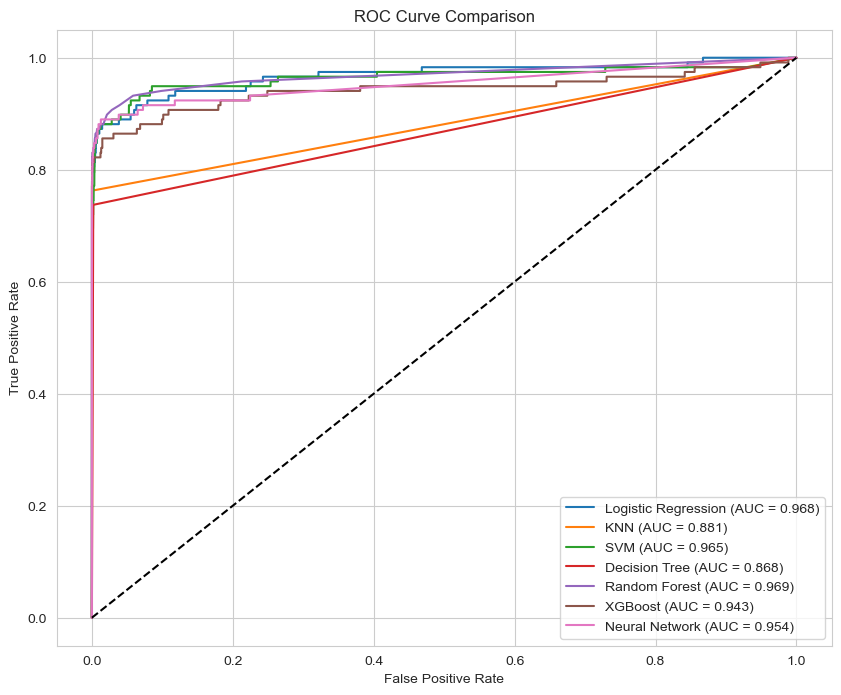

In [132]:
plt.figure(figsize=(10,8))

plt.plot(log_fpr, log_tpr,
         label=f'Logistic Regression (AUC = {log_auc:.3f})')

plt.plot(knn_fpr, knn_tpr,
         label=f'KNN (AUC = {knn_auc:.3f})')

plt.plot(svc_fpr, svc_tpr,
         label=f'SVM (AUC = {svc_auc:.3f})')

plt.plot(tree_fpr, tree_tpr,
         label=f'Decision Tree (AUC = {tree_auc:.3f})')

plt.plot(rfc_fpr, rfc_tpr,
         label=f'Random Forest (AUC = {rfc_auc:.3f})')

plt.plot(xgb_fpr, xgb_tpr,
         label=f'XGBoost (AUC = {xgb_auc:.3f})')

plt.plot(nn_fpr, nn_tpr,
         label=f'Neural Network (AUC = {nn_auc:.3f})')

# random classifier line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

# Auc Comparaison Table :

In [133]:
auc_scores = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'KNN',
        'SVM',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Neural Network'
    ],

    'AUC Score':[
        log_auc,
        knn_auc,
        svc_auc,
        tree_auc,
        rfc_auc,
        xgb_auc,
        nn_auc
    ]
})

auc_scores.sort_values(
    by='AUC Score',
    ascending=False
)

,Model,AUC Score
4,Random Forest,0.969044
0,Logistic Regression,0.967898
2,SVM,0.964747
6,Neural Network,0.953535
5,XGBoost,0.942601
1,KNN,0.881010
3,Decision Tree,0.867670


# Final Model Comparaison :
- Among all tested models, Random Forest achieved the strongest overall balance between fraud detection and false positive control. It maintained very high fraud precision (91%) while still correctly detecting 76% of fraudulent transactions, making it the most practical and production-ready solution.

- Logistic Regression and SVM achieved the highest fraud recall (88%), meaning they missed the fewest fraudulent transactions. However, both models generated extremely large numbers of false positives, making them overly aggressive for real-world deployment.

- KNN delivered surprisingly strong performance with a very good balance between recall and precision while maintaining a low false positive count. XGBoost and the Neural Network also performed strongly and demonstrated robust capability in handling imbalanced fraud detection tasks.

- The Decision Tree model produced the weakest overall results due to lower precision and weaker generalization performance.

# 8- Conclusions:

# 8.1- Key Insights :
- The dataset was extremely imbalanced, making fraud detection highly challenging.
- Accuracy alone was misleading since almost all models achieved near-perfect accuracy due to the dominance of legitimate transactions.
- Recall became one of the most important metrics because missing fraudulent transactions carries significant financial risk.
- SMOTE balancing significantly improved the models’ ability to detect fraudulent transactions.
- Ensemble-based models such as Random Forest and XGBoost achieved the strongest and most stable performance.
- Random Forest provided the best tradeoff between fraud detection capability and false positive reduction.
- Deep learning models demonstrated strong performance but did not significantly outperform advanced ensemble machine learning models on this tabular dataset.

# 8.2- Business Recomendations:
- Financial institutions should prioritize fraud recall to minimize undetected fraudulent transactions.
- Models with extremely high false positive rates, such as Logistic Regression and SVM, would require secondary verification systems before deployment.
- Random Forest is recommended as the most suitable production model due to its strong balance between fraud detection and operational efficiency.
- Fraud detection systems should continuously retrain on new transaction data since fraud patterns evolve over time.
- Threshold optimization could further improve the balance between fraud recall and false positive reduction depending on business risk tolerance.